# 运营复盘汇报模板

本 notebook 用于经营 / 增长复盘，按周、月和渠道三层维度整理 KPI、趋势变化和业务结论，适合直接用于业务周报或月报汇报。

本模板重点回答：
- 业务是否增长？
- 哪些渠道贡献最多？
- 哪些环节需要优化？
- 下一步该如何调整资源分配？

In [1]:
from pathlib import Path

import pandas as pd

from notebook_framework import (
    NotebookProject,
    ab_test_summary,
    attribution_breakdown,
    build_operational_dashboard,
    build_report_table,
    plot_metric_comparison,
    time_series_summary,
)

project = NotebookProject(repo_root=Path.cwd().resolve().parent.parent)
df = project.load_csv("notebook_env_demo.csv")
df["date"] = pd.to_datetime(df["date"])
df.head()

,date,source,region,channel,visits,orders,revenue,conversion
0,2026-01-01,search,north,organic,836,71,3474.88,0.0849
1,2026-01-01,ads,north,paid,924,60,2233.92,0.0649
2,2026-01-01,social,north,social,731,32,890.48,0.0438
3,2026-01-01,email,north,email,676,74,4346.08,0.1095
4,2026-01-02,search,south,organic,786,66,3230.88,0.0840


## 1. 复盘摘要：先看核心 KPI

建议汇报中先展示四个数字：总流量、订单量、收入、转化率。它们能快速判断业务是否健康。

In [2]:
summary = build_report_table(
    df,
    group_by="source",
    metrics={"visits": "visits", "orders": "orders", "revenue": "revenue"},
)

kpi = {
    "total_visits": int(df["visits"].sum()),
    "total_orders": int(df["orders"].sum()),
    "total_revenue": float(df["revenue"].sum()),
    "conversion_rate": float(df["orders"].sum() / df["visits"].sum()) if df["visits"].sum() else 0.0,
    "avg_order_value": float(df["revenue"].sum() / df["orders"].sum()) if df["orders"].sum() else 0.0,
}

summary.head()
kpi

{'total_visits': 134482,
 'total_orders': 10086,
 'total_revenue': 466636.56000000006,
 'conversion_rate': 0.07499888460909267,
 'avg_order_value': 46.26577037477693}

## 2. 周度趋势：看增长是否稳定

周维度更贴近运营节奏，适合判断是否有“爆发式增长”还是“持续性放缓”。

In [3]:
weekly_summary = time_series_summary(
    df,
    date_col="date",
    value_col="visits",
    group_by="source",
    freq="W-MON",
)
weekly_summary.head()

,source,date,total_visits
0,ads,2026-01-05,5273
1,ads,2026-01-12,7961
2,ads,2026-01-19,9350
3,ads,2026-01-26,10003
4,ads,2026-02-02,6347


## 3. 月度趋势：看整体经营状态

月维度适合管理层审视趋势是否持续，并判断资源投入是否形成稳定经营结构。

In [4]:
monthly_summary = time_series_summary(
    df,
    date_col="date",
    value_col="revenue",
    group_by="source",
    freq="ME",
)
monthly_summary.head()

,source,date,total_revenue
0,ads,2026-01-31,93690.72
1,email,2026-01-31,192166.32
2,search,2026-01-31,141893.84
3,social,2026-01-31,38885.68


## 4. 渠道拆解：谁在贡献收入、谁在消耗资源？

这里不只看“带来多少流量”，还要看“是否带来有效订单以及真实收入”。

In [5]:
channel_summary = build_report_table(
    df,
    group_by="channel",
    metrics={"visits": "visits", "orders": "orders", "revenue": "revenue"},
)
channel_summary.head()

,channel,visits,orders,revenue
0,paid,38934,2516,93690.72
1,organic,34273,2899,141893.84
2,social,31396,1399,38885.68
3,email,29879,3272,192166.32


d:\AI-WORKSPACE\projects\crawler\data-analysis\notebooks\notebook_framework.py:973: UserWarning: Glyph 28192 (\N{CJK UNIFIED IDEOGRAPH-6E20}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
d:\AI-WORKSPACE\projects\crawler\data-analysis\notebooks\notebook_framework.py:973: UserWarning: Glyph 36947 (\N{CJK UNIFIED IDEOGRAPH-9053}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
d:\AI-WORKSPACE\projects\crawler\data-analysis\notebooks\notebook_framework.py:973: UserWarning: Glyph 27969 (\N{CJK UNIFIED IDEOGRAPH-6D41}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
d:\AI-WORKSPACE\projects\crawler\data-analysis\notebooks\notebook_framework.py:973: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
d:\AI-WORKSPACE\projects\crawler\data-analysis\notebooks\notebook_framework.py:973: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
d:\AI-WORKSPACE

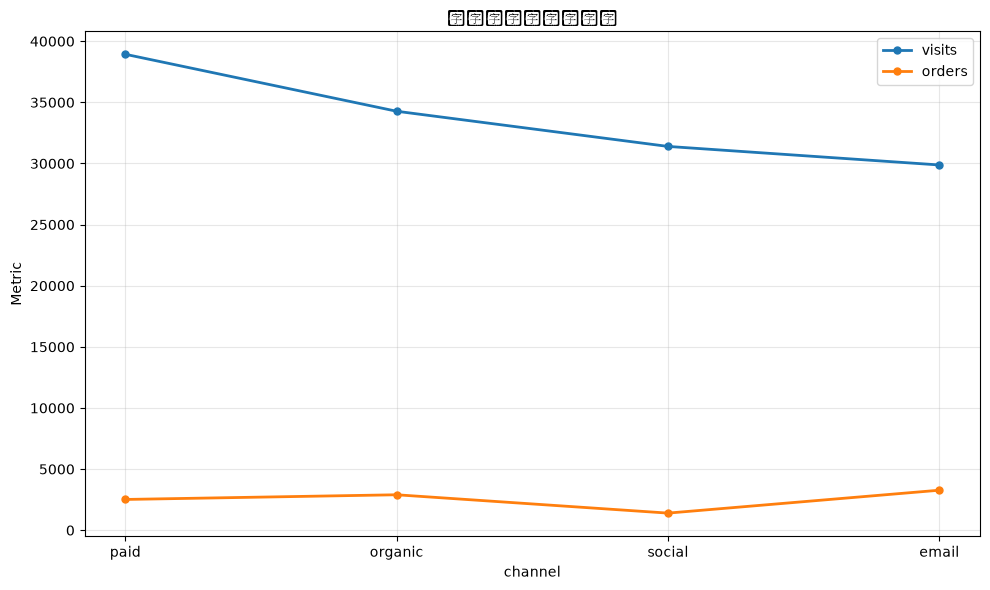

d:\AI-WORKSPACE\projects\crawler\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 28192 (\N{CJK UNIFIED IDEOGRAPH-6E20}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
d:\AI-WORKSPACE\projects\crawler\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 36947 (\N{CJK UNIFIED IDEOGRAPH-9053}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
d:\AI-WORKSPACE\projects\crawler\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 27969 (\N{CJK UNIFIED IDEOGRAPH-6D41}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
d:\AI-WORKSPACE\projects\crawler\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
d:\AI-WORKSPACE\projects\crawler\.venv\Lib\site-packages\IPython\core\events.py:101: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  func(*args, **kwa

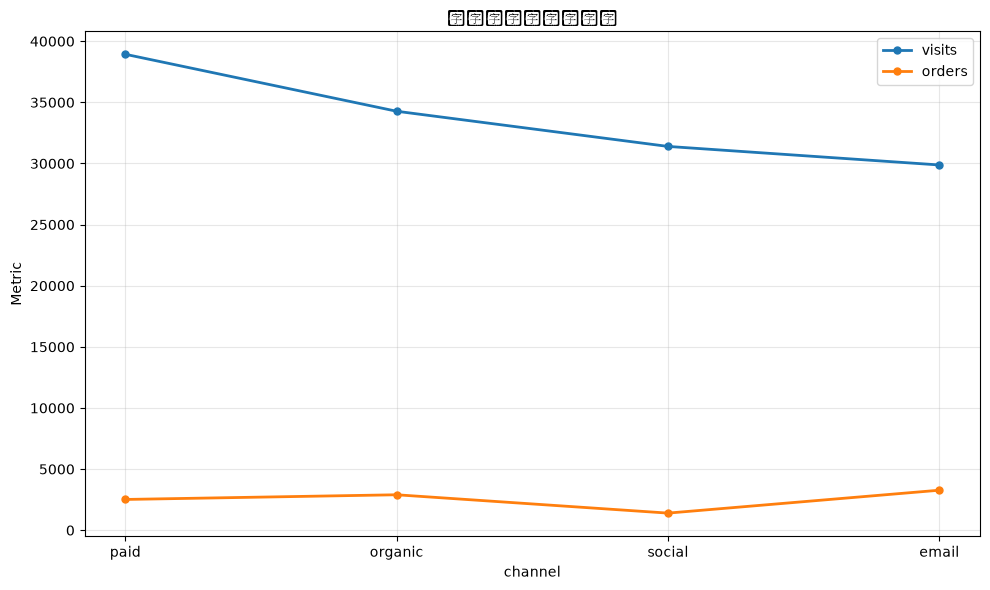

In [6]:
fig, ax = plot_metric_comparison(
    channel_summary,
    x_col="channel",
    metrics=["visits", "orders"],
    title="渠道流量与订单对比",
)
fig

## 5. 归因与实验信号

这一段用于判断增长是否来自实际渠道能力，还是简单靠量冲高。

In [7]:
ab_summary = ab_test_summary(
    df,
    variant_col="channel",
    metric_col="orders",
    baseline_variant="organic",
)

attribution = attribution_breakdown(
    df,
    user_id_col="user_id",
    channel_col="channel",
    value_col="revenue",
    conversion_col="orders",
    method="last_touch",
)

ab_summary.head()
attribution.head()

,channel,converted_users,revenue,revenue_share
0,email,30,192166.32,0.411812
1,organic,30,141893.84,0.304078
2,paid,30,93690.72,0.200779
3,social,30,38885.68,0.083332


## 6. 业务结论口径（建议直接用于汇报）

- 如果总流量增长，而订单增速低于流量增速，说明渠道质量下降，需要检查转化链路。
- 如果 revenue 增长快于 orders，说明客单价或高价值订单占比提升，业务结构改善。
- 如果某渠道带来高流量但低收入，说明其获客成本和转化效率不均衡，需要从投放策略和落地页优化入手。
- 如果实验结果中某变体明显优于 baseline，说明增长策略具备可复制性，可优先扩大资源投入。

In [ ]:
from typing import Any


def run_operational_review(frame: pd.DataFrame) -> dict[Any,Any]:
    return build_operational_dashboard(
        frame,
        date_col="date",
        group_by="source",
        metrics={"visits": "visits", "orders": "orders", "revenue": "revenue"},
        channel_col="channel",
        baseline_variant="organic",
    )

review = run_operational_review(df)
review["summary"].head()

,source,visits,orders,revenue
0,ads,38934,2516,93690.72
1,search,34273,2899,141893.84
2,social,31396,1399,38885.68
3,email,29879,3272,192166.32


## 7. 一页式汇报建议

若要直接呈现给管理层，建议使用以下顺序：
1. KPI 总览卡片
2. 周趋势图
3. 月度趋势图
4. 渠道贡献排行榜
5. 归因 / 实验结论
6. 行动建议

这版已经更接近真实业务复盘文档的口径，需要时可直接替换数据源并输出汇报版结果。